## Assignment 1

Design a McCulloch-Pitts neural network which behaves as AND function
using Adaline learning. Consider unipolar case. Perform analysis by varying NN
parameters.

**Meaning:**

Use the simple MCP-style neuron architecture (single neuron with weighted inputs and a threshold), but train its weights using the ADALINE/LMS update rule rather than choosing the weights manually.

**Remember:**

McCulloch-Pitts neuron → single neuron

ADALINE learning → train the weights using the LMS (delta) rule

Unipolar → outputs are 0 and 1

**STEP 1: TRAINING DATA**

For AND,

| x1 | x2 | Target |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 0      |
| 1  | 0  | 0      |
| 1  | 1  | 1      |



**STEP 2: Algorithm**

**Initialize:**

w1
w2
bias
learning rate

**For every sample,**

yin = w1.x1 + w2.x2 + bias

error = target - yin

w1 += α * error * x1

w2 += α * error * x2

bias += α * error

Repeat **until** convergence.

**STEP 3: PYTHON IMPLEMENTATION**

In [2]:
# AND gate using ADALINE learning

inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

targets = [0, 0, 0, 1]

# Initial weights
w1 = 0.0
w2 = 0.0
b = 0.0

alpha = 0.1
epochs = 20

for epoch in range(epochs):

    for (x1, x2), t in zip(inputs, targets):

        # Linear output
        y_in = w1*x1 + w2*x2 + b

        error = t - y_in

        # ADALINE update
        w1 += alpha * error * x1
        w2 += alpha * error * x2
        b += alpha * error

print("Weights:")
print("w1 =", w1)
print("w2 =", w2)
print("bias =", b)

Weights:
w1 = 0.4534942664741924
w2 = 0.42649746140251255
bias = -0.1404474278250382


**STEP 4: TESTING**

ADALINE trains on the linear output, but when using it as a logic gate we apply a threshold.

In [3]:
print("\nTesting AND Gate")

for x1, x2 in inputs:

    y_in = w1*x1 + w2*x2 + b

    # MCP threshold
    if y_in >= 0.5:
        y = 1
    else:
        y = 0

    print(x1, x2, "->", y)


Testing AND Gate
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


**STEP 5: "Varying NN Parameters"**

The easiest parameters to vary are:

**Learning rate (α)**

In [4]:
alpha = 0.01
alpha = 0.1
alpha = 0.5

Smaller α → slower convergence.

Larger α → faster updates but may oscillate.

**Initial weights**

In [5]:
w1 = 0.5
w2 = -0.3

# or

# w1 = 0
# w2 = 0

Compare how quickly the network converges in these cases

**Number of epochs**

In [6]:
epochs = 10
epochs = 20
epochs = 50

Observe whether the weights stabilize.

**STEP 6: ANALYSIS**

In [7]:
def train_adaline(alpha, epochs, w1, w2, b):

    # Training data (AND gate)
    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]

    targets = [0, 0, 0, 1]

    # -------- Training --------
    for epoch in range(epochs):

        for (x1, x2), t in zip(inputs, targets):

            # Linear output
            y_in = w1 * x1 + w2 * x2 + b

            # Error
            error = t - y_in

            # ADALINE update
            w1 += alpha * error * x1
            w2 += alpha * error * x2
            b += alpha * error

    # -------- Results --------
    print(f"\nalpha = {alpha}, epochs = {epochs}")
    print(f"Final Weights: w1 = {w1:.4f}, w2 = {w2:.4f}, bias = {b:.4f}")

    print("\nTesting:")

    for x1, x2 in inputs:

        y_in = w1 * x1 + w2 * x2 + b

        # MCP Threshold
        y = 1 if y_in >= 0.5 else 0

        print(f"{x1} {x2} -> {y} (y_in = {y_in:.4f})")

    return w1, w2, b

**Vary learning rate**

In [8]:
train_adaline(alpha=0.01, epochs=20, w1=0, w2=0, b=0)


alpha = 0.01, epochs = 20
Final Weights: w1 = 0.1336, w2 = 0.1334, bias = 0.0951

Testing:
0 0 -> 0 (y_in = 0.0951)
0 1 -> 0 (y_in = 0.2284)
1 0 -> 0 (y_in = 0.2287)
1 1 -> 0 (y_in = 0.3621)


(0.13362812750183223, 0.13337969569075558, 0.09506317137328063)

In [9]:
train_adaline(alpha=0.1, epochs=20, w1=0, w2=0, b=0)


alpha = 0.1, epochs = 20
Final Weights: w1 = 0.4535, w2 = 0.4265, bias = -0.1404

Testing:
0 0 -> 0 (y_in = -0.1404)
0 1 -> 0 (y_in = 0.2861)
1 0 -> 0 (y_in = 0.3130)
1 1 -> 1 (y_in = 0.7395)


(0.4534942664741924, 0.42649746140251255, -0.1404474278250382)

In [10]:
train_adaline(alpha=0.5, epochs=20, w1=0, w2=0, b=0)


alpha = 0.5, epochs = 20
Final Weights: w1 = 1.0000, w2 = 0.7500, bias = -0.5000

Testing:
0 0 -> 0 (y_in = -0.5000)
0 1 -> 0 (y_in = 0.2500)
1 0 -> 1 (y_in = 0.5000)
1 1 -> 1 (y_in = 1.2500)


(0.9999990463256836, 0.7499949932098389, -0.49998903274536133)

**Vary epochs**

In [11]:
train_adaline(alpha=0.1, epochs=10, w1=0, w2=0, b=0)


alpha = 0.1, epochs = 10
Final Weights: w1 = 0.3498, w2 = 0.3303, bias = -0.0056

Testing:
0 0 -> 0 (y_in = -0.0056)
0 1 -> 0 (y_in = 0.3247)
1 0 -> 0 (y_in = 0.3441)
1 1 -> 1 (y_in = 0.6744)


(0.34975884045409855, 0.33027309783091086, -0.005612672050640838)

In [12]:
train_adaline(alpha=0.1, epochs=50, w1=0, w2=0, b=0)


alpha = 0.1, epochs = 50
Final Weights: w1 = 0.5428, w2 = 0.5145, bias = -0.2602

Testing:
0 0 -> 0 (y_in = -0.2602)
0 1 -> 0 (y_in = 0.2543)
1 0 -> 0 (y_in = 0.2826)
1 1 -> 1 (y_in = 0.7971)


(0.5427622107941813, 0.51449174089811, -0.26017323923797886)

In [13]:
train_adaline(alpha=0.1, epochs=100, w1=0, w2=0, b=0)


alpha = 0.1, epochs = 100
Final Weights: w1 = 0.5551, w2 = 0.5273, bias = -0.2772

Testing:
0 0 -> 0 (y_in = -0.2772)
0 1 -> 0 (y_in = 0.2501)
1 0 -> 0 (y_in = 0.2779)
1 1 -> 1 (y_in = 0.8053)


(0.5551419200773078, 0.5273415087403043, -0.27720415715508595)

**Vary initial weights**

In [14]:
train_adaline(alpha=0.1, epochs=20, w1=0, w2=0, b=0)


alpha = 0.1, epochs = 20
Final Weights: w1 = 0.4535, w2 = 0.4265, bias = -0.1404

Testing:
0 0 -> 0 (y_in = -0.1404)
0 1 -> 0 (y_in = 0.2861)
1 0 -> 0 (y_in = 0.3130)
1 1 -> 1 (y_in = 0.7395)


(0.4534942664741924, 0.42649746140251255, -0.1404474278250382)

In [15]:
train_adaline(alpha=0.1, epochs=20, w1=1, w2=1, b=0)


alpha = 0.1, epochs = 20
Final Weights: w1 = 0.5995, w2 = 0.5742, bias = -0.3387

Testing:
0 0 -> 0 (y_in = -0.3387)
0 1 -> 0 (y_in = 0.2354)
1 0 -> 0 (y_in = 0.2607)
1 1 -> 1 (y_in = 0.8349)


(0.5994829417860212, 0.5741886697793512, -0.33874765996728773)

In [16]:
train_adaline(alpha=0.1, epochs=20, w1=-1, w2=0.5, b=0)


alpha = 0.1, epochs = 20
Final Weights: w1 = 0.3342, w2 = 0.4695, bias = -0.0866

Testing:
0 0 -> 0 (y_in = -0.0866)
0 1 -> 0 (y_in = 0.3829)
1 0 -> 0 (y_in = 0.2477)
1 1 -> 1 (y_in = 0.7172)


(0.33422292878158966, 0.4695001931644145, -0.08657195763143524)

## Assignment 2, 3, and 4

Now, instead of hardcoding the gate inside the function, we make the training data an argument, so that we may train the neural network to make it function like any kind of gate that we want it to be:

In [17]:
def train_adaline(targets, inputs, alpha, epochs, w1, w2, b):

    for epoch in range(epochs):

        for (x1, x2), t in zip(inputs, targets):

            # Linear output
            y_in = w1 * x1 + w2 * x2 + b

            # Error
            error = t - y_in

            # ADALINE update
            w1 += alpha * error * x1
            w2 += alpha * error * x2
            b += alpha * error

    # -------- Results --------
    print(f"\nalpha = {alpha}, epochs = {epochs}")
    print(f"Final Weights: w1 = {w1:.4f}, w2 = {w2:.4f}, bias = {b:.4f}")

    print("\nTesting:")

    for x1, x2 in inputs:

        y_in = w1 * x1 + w2 * x2 + b

        # MCP Threshold
        y = 1 if y_in >= 0.5 else 0

        print(f"{x1} {x2} -> {y} (y_in = {y_in:.4f})")

    return w1, w2, b

## **Assignment 2:** 

Develop a McCulloch-Pitss neural net for OR, NAND and NOR gate and draw neural nets.

In [18]:
# OR gate

targets = [0, 1, 1, 1]

inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
    ]

    
alpha = 0.5
epochs = 100
w1 = 0.5
w2 = 0.5
b = 0.5

train_adaline(targets, inputs, alpha, epochs, w1, w2, b)


alpha = 0.5, epochs = 100
Final Weights: w1 = 0.0000, w2 = 0.2500, bias = 0.5000

Testing:
0 0 -> 1 (y_in = 0.5000)
0 1 -> 1 (y_in = 0.7500)
1 0 -> 1 (y_in = 0.5000)
1 1 -> 1 (y_in = 0.7500)


(0.0, 0.25, 0.5)

In [19]:
# NAND gate

targets = [1, 1, 1, 0]

inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
    ]

    
alpha = 0.5
epochs = 100
w1 = 0.5
w2 = 0.5
b = 0.5

train_adaline(targets, inputs, alpha, epochs, w1, w2, b)


alpha = 0.5, epochs = 100
Final Weights: w1 = -1.0000, w2 = -0.7500, bias = 1.5000

Testing:
0 0 -> 1 (y_in = 1.5000)
0 1 -> 1 (y_in = 0.7500)
1 0 -> 1 (y_in = 0.5000)
1 1 -> 0 (y_in = -0.2500)


(-1.0, -0.75, 1.5)

In [20]:
# NOR gate

targets = [1, 0, 0, 0]

inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
    ]

    
alpha = 0.5
epochs = 100
w1 = 0.5
w2 = 0.5
b = 0.5

train_adaline(targets, inputs, alpha, epochs, w1, w2, b)


alpha = 0.5, epochs = 100
Final Weights: w1 = 0.0000, w2 = -0.2500, bias = 0.5000

Testing:
0 0 -> 1 (y_in = 0.5000)
0 1 -> 0 (y_in = 0.2500)
1 0 -> 1 (y_in = 0.5000)
1 1 -> 0 (y_in = 0.2500)


(0.0, -0.25, 0.5)

**Visualization Part:** 

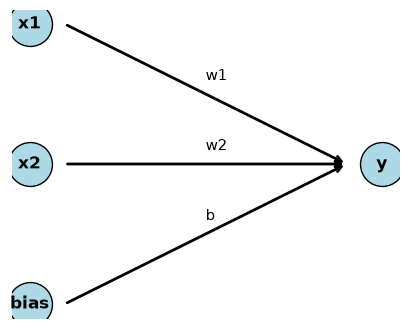

In [24]:
 # %pip install matplotlib

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

# nodes
ax.scatter([0, 0, 0, 1], [1, 0, -1, 0], s=1000, color="lightblue", edgecolor="black", zorder=3)
for label, x, y in [("x1", 0, 1), ("x2", 0, 0), ("bias", 0, -1), ("y", 1, 0)]:
    ax.text(x, y, label, ha="center", va="center", fontsize=12, weight="bold")

# arrows
for start, end, w in [(("x1", 0, 1), ("y", 1, 0), "w1"),
                      (("x2", 0, 0), ("y", 1, 0), "w2"),
                      (("bias", 0, -1), ("y", 1, 0), "b")]:
    (x0, y0), (x1, y1) = (start[1], start[2]), (end[1], end[2])
    ax.annotate(
        "",
        xy=(x1 - 0.1, y1),
        xytext=(x0 + 0.1, y0),
        arrowprops=dict(arrowstyle="->", lw=2),
    )
    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.1, w, fontsize=11)

ax.axis("off")
plt.show()

## Assignment 3:

Perform test for bipolar model as well.

In [25]:
# Bipolar ADALINE model test

def train_adaline_bipolar(targets, alpha=0.1, epochs=20, w1=0.0, w2=0.0, b=0.0):

    bipolar_inputs = [
        [-1, -1],
        [-1,  1],
        [ 1, -1],
        [ 1,  1]
    ]

    for epoch in range(epochs):
        for (x1, x2), t in zip(bipolar_inputs, targets):
            y_in = w1 * x1 + w2 * x2 + b
            error = t - y_in
            w1 += alpha * error * x1
            w2 += alpha * error * x2
            b += alpha * error

    print(f"\nBipolar ADALINE: alpha = {alpha}, epochs = {epochs}")
    print(f"Final Weights: w1 = {w1:.4f}, w2 = {w2:.4f}, bias = {b:.4f}")

    print("\nTesting bipolar gate:")
    for x1, x2 in bipolar_inputs:
        y_in = w1 * x1 + w2 * x2 + b
        y = 1 if y_in >= 0 else -1
        print(f"{x1} {x2} -> {y} (y_in = {y_in:.4f})")

    return w1, w2, b

bipolar_targets_and = [-1, -1, -1, 1]

train_adaline_bipolar(bipolar_targets_and)


Bipolar ADALINE: alpha = 0.1, epochs = 20
Final Weights: w1 = 0.5294, w2 = 0.5588, bias = -0.4999

Testing bipolar gate:
-1 -1 -> -1 (y_in = -1.5881)
-1 1 -> -1 (y_in = -0.4705)
1 -1 -> -1 (y_in = -0.5294)
1 1 -> 1 (y_in = 0.5882)


(0.5293720756864557, 0.5588031612441573, -0.49994691004642094)

In [30]:
bipolar_targets_xor = [1, -1, -1, 1]

train_adaline_bipolar(bipolar_targets_xor, b = -0.5)


Bipolar ADALINE: alpha = 0.1, epochs = 20
Final Weights: w1 = 0.0588, w2 = 0.1176, bias = -0.0000

Testing bipolar gate:
-1 -1 -> -1 (y_in = -0.1765)
-1 1 -> 1 (y_in = 0.0588)
1 -1 -> -1 (y_in = -0.0588)
1 1 -> 1 (y_in = 0.1764)


(0.05881822534839812, 0.11761805005174882, -2.451412445277079e-05)

**A single McCulloch-Pitts neuron **cannot** implement XOR.**

XOR is not linearly separable.

A single MCP neuron (or single ADALINE/perceptron) can only represent linearly separable functions like AND, OR, NAND, NOR.

**XOR requires at least two layers or multiple neurons with a hidden combination.**

## Assignment 4:

Implement McCulloch-Pitts neural network model for XOR and give all
the formula you used in the implementation. Draw the MLPs used for the implementation of
above functions.

In [32]:
bipolar_targets_xor = [1, -1, -1, 1]

train_adaline_bipolar(bipolar_targets_xor, b = 0.5)


Bipolar ADALINE: alpha = 0.1, epochs = 20
Final Weights: w1 = 0.0588, w2 = 0.1177, bias = 0.0000

Testing bipolar gate:
-1 -1 -> -1 (y_in = -0.1764)
-1 1 -> 1 (y_in = 0.0589)
1 -1 -> -1 (y_in = -0.0588)
1 1 -> 1 (y_in = 0.1765)


(0.05881934274588127, 0.11765932093177625, 3.435637828075322e-05)

## Assignment 5:

Implement MLP model for XOR by using backpropagation algorithm

In [35]:
# Bipolar XOR using MLP and Backpropagation

import numpy as np

def train_mlp_bipolar(targets, alpha=0.1, epochs=10000):

    bipolar_inputs = [
        [-1, -1],
        [-1,  1],
        [ 1, -1],
        [ 1,  1]
    ]

    # 2 inputs -> 2 hidden neurons
    w1 = np.random.randn(2) * 0.5
    w2 = np.random.randn(2) * 0.5
    bh = np.zeros(2)

    # 2 hidden neurons -> 1 output neuron
    wo = np.random.randn(2) * 0.5
    bo = 0.0

    for epoch in range(epochs):
        for (x1, x2), t in zip(bipolar_inputs, targets):

            x = np.array([x1, x2])

            # Forward propagation
            h_in = w1 * x1 + w2 * x2 + bh
            h = np.tanh(h_in)

            y_in = np.dot(wo, h) + bo
            y = np.tanh(y_in)

            # Backpropagation
            error = t - y

            delta_o = error * (1 - y**2)
            delta_h = (1 - h**2) * wo * delta_o

            # Update output weights
            wo += alpha * delta_o * h
            bo += alpha * delta_o

            # Update hidden weights
            w1 += alpha * delta_h * x1
            w2 += alpha * delta_h * x2
            bh += alpha * delta_h

    print(f"\nBipolar MLP XOR: alpha = {alpha}, epochs = {epochs}")
    print(f"Output Weights: {wo}")
    print(f"Output Bias: {bo:.4f}")

    print("\nTesting bipolar XOR:")
    for x1, x2 in bipolar_inputs:

        h_in = w1 * x1 + w2 * x2 + bh
        h = np.tanh(h_in)

        y_in = np.dot(wo, h) + bo
        y = np.tanh(y_in)

        result = 1 if y >= 0 else -1

        print(f"{x1} {x2} -> {result} (y = {y:.4f})")


bipolar_targets_xor = [-1, 1, 1, -1]

train_mlp_bipolar(bipolar_targets_xor)


Bipolar MLP XOR: alpha = 0.1, epochs = 10000
Output Weights: [2.98732471 2.97290222]
Output Bias: 2.7096

Testing bipolar XOR:
-1 -1 -> -1 (y = -0.9917)
-1 1 -> 1 (y = 0.9884)
1 -1 -> 1 (y = 0.9885)
1 1 -> -1 (y = -0.9917)


unlike ADALINE's linear activation, the hidden and output neurons use tanh, which gives outputs in the bipolar range [-1, +1].